# Archivo para generar los gráficos

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

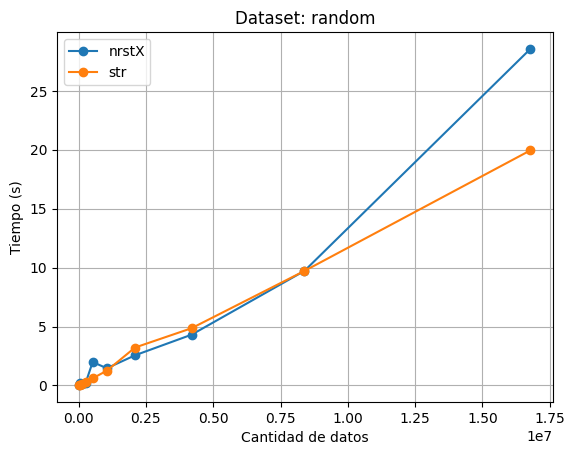

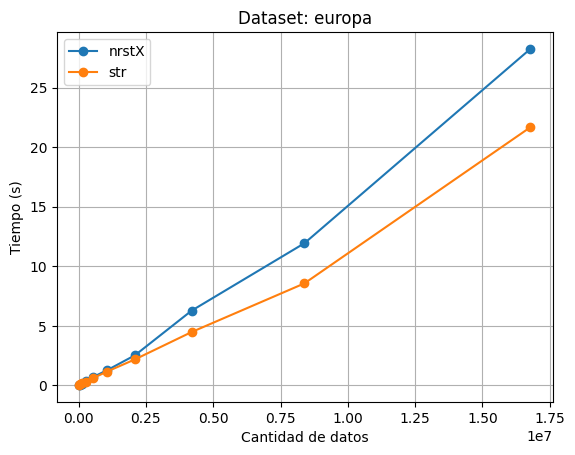

In [40]:
# Cargar datos
df = pd.read_csv("../arboles/tiempos.txt")

# Separar columna "archivo" en partes
# arbol_<dataset>_<modelo>
df[['arbol', 'dataset', 'modelo']] = df['archivo'].str.split('_', n=2, expand=True)

# Nos quedamos solo con dataset y modelo reales
df = df[['dataset', 'modelo', 'datos', 'tiempo']]

# Agrupar por dataset
datasets = df['dataset'].unique()

for dataset in datasets:
    subset = df[df['dataset'] == dataset]

    plt.figure()

    # Obtener modelos distintos dentro de ese dataset
    modelos = subset['modelo'].unique()

    for modelo in modelos:
        data_modelo = subset[subset['modelo'] == modelo]

        # Ordenar por cantidad de datos (importante para la curva)
        data_modelo = data_modelo.sort_values(by='datos')

        plt.plot(
            data_modelo['datos'],
            data_modelo['tiempo'],
            marker='o',
            label=modelo
        )

    plt.title(f"Dataset: {dataset}")
    plt.xlabel("Cantidad de datos")
    plt.ylabel("Tiempo (s)")
    plt.legend()
    plt.grid()

    # Guardar gráfico
    plt.savefig(f"grafico_construccion_arboles_{dataset}.png")

    # Mostrar gráfico (opcional)
    plt.show()

  dataset modelo  largo_rectangulo  lecturas    puntos
0  europa  nrstX            0.0025    110.15     78.32
1  europa  nrstX            0.0050    215.57    511.63
2  europa  nrstX            0.0100    372.15   1108.49
3  europa  nrstX            0.0250   1281.27   8713.25
4  europa  nrstX            0.0500   2476.72  42718.82
['europa' 'random']


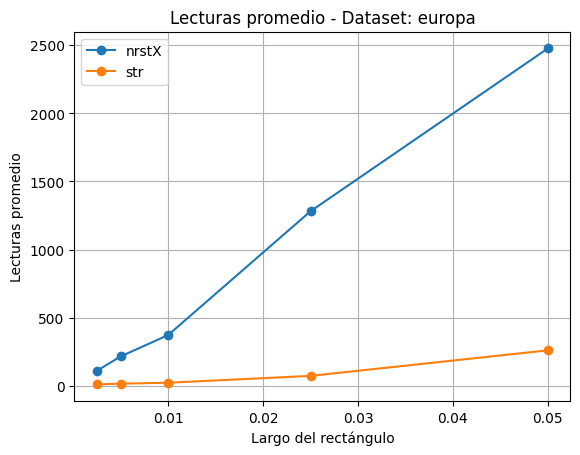

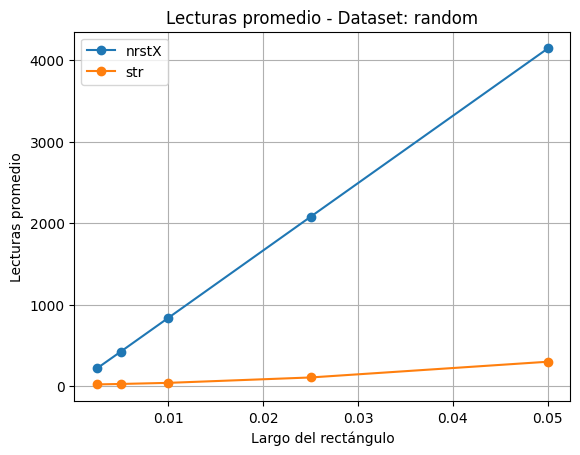

  dataset modelo  largo_rectangulo  lecturas    puntos
0  europa  nrstX            0.0025    110.15     78.32
1  europa  nrstX            0.0050    215.57    511.63
2  europa  nrstX            0.0100    372.15   1108.49
3  europa  nrstX            0.0250   1281.27   8713.25
4  europa  nrstX            0.0500   2476.72  42718.82
  dataset modelo  largo_rectangulo  lecturas    puntos
5  europa    str            0.0025      9.79     78.32
6  europa    str            0.0050     15.28    511.63
7  europa    str            0.0100     22.21   1108.49
8  europa    str            0.0250     72.48   8713.25
9  europa    str            0.0500    260.13  42718.82


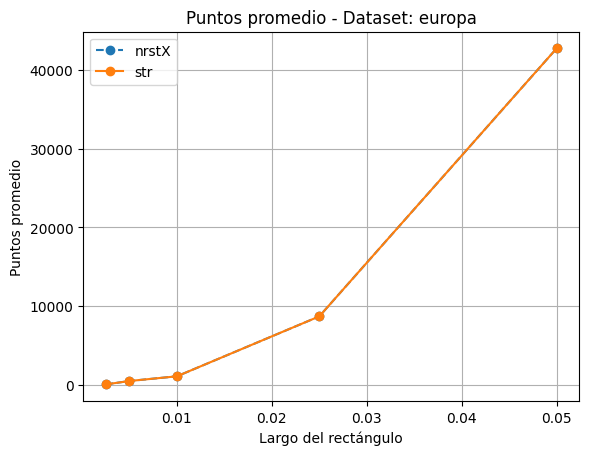

   dataset modelo  largo_rectangulo  lecturas    puntos
10  random  nrstX            0.0025    217.89    104.55
11  random  nrstX            0.0050    423.14    424.13
12  random  nrstX            0.0100    836.60   1681.13
13  random  nrstX            0.0250   2078.02  10491.87
14  random  nrstX            0.0500   4144.26  41947.32
   dataset modelo  largo_rectangulo  lecturas    puntos
15  random    str            0.0025     21.32    104.55
16  random    str            0.0050     26.95    424.13
17  random    str            0.0100     40.41   1681.13
18  random    str            0.0250    106.67  10491.87
19  random    str            0.0500    299.81  41947.32


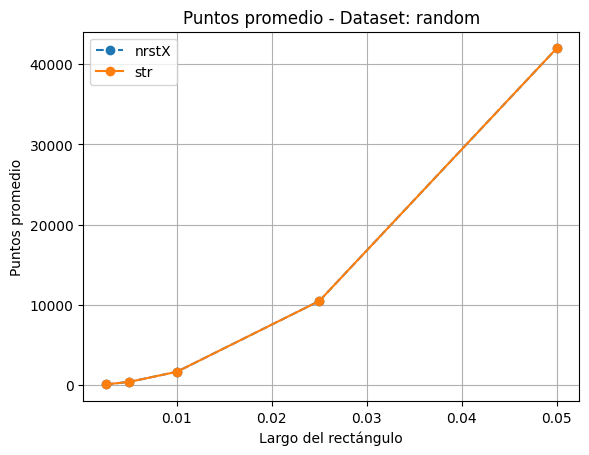

In [41]:
# Cargar datos
df = pd.read_csv("../arboles/metricas.txt")

# --- Parsear columna "arbol"
def parse_arbol(s):
    formated = s.replace(".bin", "").split("/")[1]
    parts = formated.split("_")
    dataset = parts[1]
    modelo = parts[2] # por si modelo tiene underscores
    return dataset, modelo

df[['dataset', 'modelo']] = df['arbol'].apply(
    lambda x: pd.Series(parse_arbol(x))
)

# --- AGRUPAR DATOS (promedios)
grouped = df.groupby(['dataset', 'modelo', 'largo_rectangulo']).agg({
    'lecturas': 'mean',
    'puntos': 'mean'
}).reset_index()

print(grouped.head())

# Obtener datasets únicos
datasets = grouped['dataset'].unique()
print(datasets)

# =========================================================
# 1️⃣ GRAFICOS: LECTURAS PROMEDIO
# =========================================================
for dataset in datasets:
    subset = grouped[grouped['dataset'] == dataset]

    plt.figure()

    for modelo in subset['modelo'].unique():
        data_modelo = subset[subset['modelo'] == modelo]
        data_modelo = data_modelo.sort_values(by='largo_rectangulo')

        plt.plot(
            data_modelo['largo_rectangulo'],
            data_modelo['lecturas'],
            marker='o',
            label=modelo
        )

    plt.title(f"Lecturas promedio - Dataset: {dataset}")
    plt.xlabel("Largo del rectángulo")
    plt.ylabel("Lecturas promedio")
    plt.legend()
    plt.grid()

    plt.savefig(f"grafico_lecturas_{dataset}.png")
    
    plt.show()


# =========================================================
# 2️⃣ GRAFICOS: PUNTOS PROMEDIO (sin barras aún)
# =========================================================
for dataset in datasets:
    subset = grouped[grouped['dataset'] == dataset]

    plt.figure()
    
    for modelo in subset['modelo'].unique():
        data_modelo = subset[subset['modelo'] == modelo]
        print(data_modelo.head())
        data_modelo = data_modelo.sort_values(by='largo_rectangulo')

        plt.plot(
            data_modelo['largo_rectangulo'],
            data_modelo['puntos'],
            marker='o',
            linestyle='--' if modelo == 'nrstX' else '-',
            label=modelo
        )

    plt.title(f"Puntos promedio - Dataset: {dataset}")
    plt.xlabel("Largo del rectángulo")
    plt.ylabel("Puntos promedio")
    plt.legend()
    plt.grid()
    
    plt.savefig(f"grafico_puntos_encontrados_{dataset}.png")

    plt.show()

  dataset modelo largo_rectangulo  lecturas                  puntos  \
                                       mean          std       mean   
0  random  nrstX           0.0025   164.020   166.997697     91.435   
1  random  nrstX           0.0050   319.355   301.503784    467.880   
2  random  nrstX           0.0100   604.375   457.116915   1394.810   
3  random  nrstX           0.0250  1679.645  1663.929894   9602.560   
4  random  nrstX           0.0500  3310.490  2657.721738  42333.070   

                 
            std  
0    292.374176  
1   1582.648685  
2   2473.919069  
3  21214.424617  
4  93128.283792  


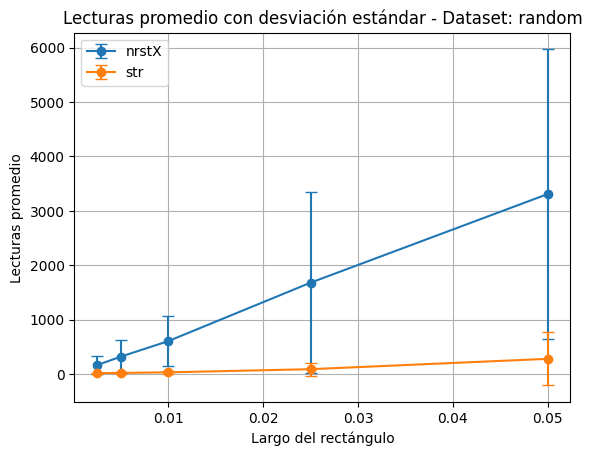

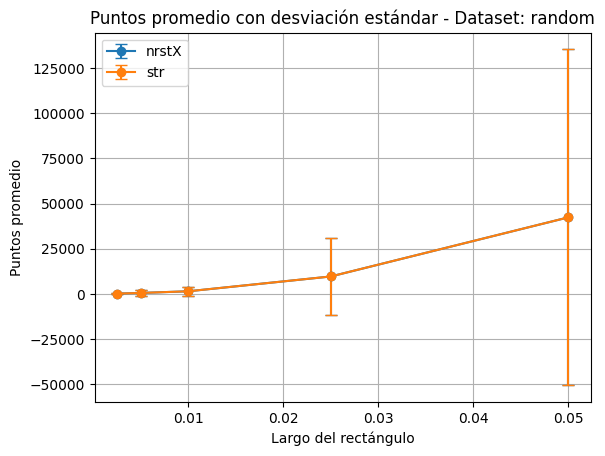

In [42]:
# =========================
# Cargar datos
# =========================
df = pd.read_csv("../arboles/metricas.txt")

# =========================
# Parsear columna "arbol"
# arbol_<dataset>_<modelo>_24.bin
# =========================
def parse_arbol(s):
    formated = s.replace(".bin", "").split("/")[1]
    parts = formated.split("_")
    modelo = "_".join(parts[2:-1])
    return dataset, modelo

df[['dataset', 'modelo']] = df['arbol'].apply(
    lambda x: pd.Series(parse_arbol(x))
)

# =========================
# Agrupar: promedio + std
# =========================
grouped = df.groupby(['dataset', 'modelo', 'largo_rectangulo']).agg({
    'lecturas': ['mean', 'std'],
    'puntos': ['mean', 'std']
}).reset_index()
print(grouped.head())
# Aplanar nombres de columnas
grouped.columns = [
    'dataset', 'modelo', 'largo_rectangulo',
    'lecturas_mean', 'lecturas_std',
    'puntos_mean', 'puntos_std'
]

# =========================
# Obtener datasets
# =========================
datasets = grouped['dataset'].unique()


# =========================================================
# 1️⃣ GRAFICOS: LECTURAS + BARRAS DE ERROR
# =========================================================
for dataset in datasets:
    subset = grouped[grouped['dataset'] == dataset]

    plt.figure()

    for modelo in subset['modelo'].unique():
        data_modelo = subset[subset['modelo'] == modelo]
        data_modelo = data_modelo.sort_values(by='largo_rectangulo')

        plt.errorbar(
            data_modelo['largo_rectangulo'],
            data_modelo['lecturas_mean'],
            yerr=data_modelo['lecturas_std'],
            marker='o',
            capsize=4,
            label=modelo
        )

    plt.title(f"Lecturas promedio con desviación estándar - Dataset: {dataset}")
    plt.xlabel("Largo del rectángulo")
    plt.ylabel("Lecturas promedio")
    plt.legend()
    plt.grid()

    plt.savefig(f"grafico_lecturas_std_{dataset}.png")
    plt.show()


# =========================================================
# 2️⃣ GRAFICOS: PUNTOS + BARRAS DE ERROR
# =========================================================
for dataset in datasets:
    subset = grouped[grouped['dataset'] == dataset]

    plt.figure()

    for modelo in subset['modelo'].unique():
        data_modelo = subset[subset['modelo'] == modelo]
        data_modelo = data_modelo.sort_values(by='largo_rectangulo')

        plt.errorbar(
            data_modelo['largo_rectangulo'],
            data_modelo['puntos_mean'],
            yerr=data_modelo['puntos_std'],
            marker='o',
            capsize=4,
            label=modelo
        )

    plt.title(f"Puntos promedio con desviación estándar - Dataset: {dataset}")
    plt.xlabel("Largo del rectángulo")
    plt.ylabel("Puntos promedio")
    plt.legend()
    plt.grid()

    plt.savefig(f"grafico_puntos_encontrado_std_{dataset}.png")
    plt.show()